# It's Raining Cats Dataset

Dataset loaded from Kaggle: `joannanplkrk/its-raining-cats`

## Loading and Exploring Data

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
from sklearn.cluster import KMeans
from sklearn.tree import DecisionTreeClassifier


## Data Visualization: Cat Breeds Distribution

In [2]:

df = pd.read_csv('data/its-raining-cats/cat_breeds_clean.csv', sep=';', encoding='utf-8')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (1071, 17)


,Breed,Age_in_years,Age_in_months,Gender,Neutered_or_spayed,Body_length,Weight,Fur_colour_dominant,Fur_pattern,Eye_colour,Allowed_outdoor,Preferred_food,Owner_play_time_minutes,Sleep_time_hours,Country,Latitude,Longitude
0,Angora,0.25,3,female,False,19,2.0,white,solid,blue,False,wet,46,16,France,43.296482,5.369780
1,Angora,0.33,4,male,False,19,2.5,white,solid,blue,False,wet,48,16,France,43.611660,3.877710
2,Angora,0.50,6,male,False,20,2.8,black,solid,green,False,wet,41,11,France,44.837789,-0.579180
3,Angora,0.50,6,female,False,21,3.0,white,solid,blue,False,wet,24,8,France,43.611660,3.877710
4,Angora,0.50,6,male,False,21,3.0,red/cream,tabby,green,False,wet,51,10,France,48.864716,2.349014


## Linear Regression: Predicting Weight

Text(0.5, 1.0, 'Distribution of Cat Breeds')

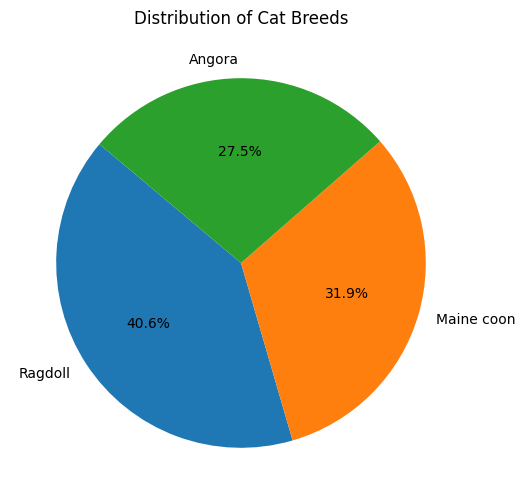

In [3]:
breed_counts = df['Breed'].value_counts()
plt.figure(figsize=(10, 6))
plt.pie(breed_counts, labels=breed_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Cat Breeds')  

In [4]:

model_data = df[['Breed', 'Gender', 'Weight']].dropna()

X = pd.get_dummies(model_data[['Breed', 'Gender']], drop_first=True)
y = model_data['Weight']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)


y_pred = lr_model.predict(X_test)


mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared: {r2:.2f}")


results = pd.DataFrame({'Actual Weight': y_test, 'Predicted Weight': y_pred})
print("\\nSample Predictions:")
display(results.head())

Mean Squared Error: 3.62
R-squared: 0.33
\nSample Predictions:


,Actual Weight,Predicted Weight
184,4.70,4.547067
572,9.70,7.621685
309,3.80,7.621685
930,4.65,4.836606
711,6.80,6.474104


In [5]:
def predict_weight(breed, gender):
    input_data = pd.DataFrame(columns=X_train.columns, data=[[0]*len(X_train.columns)])
    
    breed_col = f'Breed_{breed}'
    if breed_col in input_data.columns:
        input_data[breed_col] = 1
    else:
        print(f"Warning: Breed '{breed}' not found in training data. Prediction may be inaccurate.")
        return None

    gender_col = f'Gender_{gender}'
    if gender_col in input_data.columns:
        input_data[gender_col] = 1
    else:
        print(f"Warning: Gender '{gender}' not found in training data. Prediction may be inaccurate.")
        return None

    if lr_model is None:
        print("Error: Linear Regression model is not trained.")
        return None
    else:
        prediction = lr_model.predict(input_data)[0]
        return prediction



## K-Means Clustering: Sleep Time Analysis

In [6]:

predicted_value = predict_weight('Maine coon', 'male')
print(f"Predicted Weight: {predicted_value:.2f}")

Predicted Weight: 7.62


C:\Users\retra\AppData\Roaming\Python\Python311\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


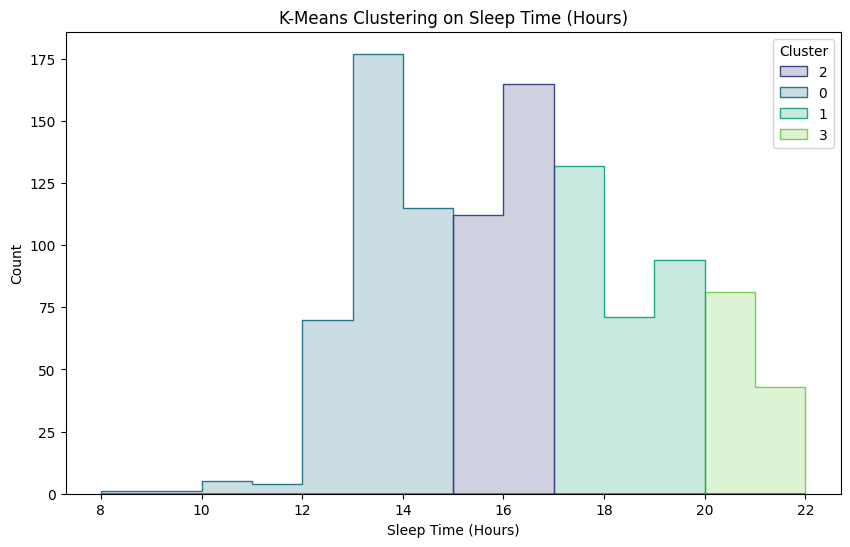

In [7]:
cluster_num = 4
X_sleep = df[['Sleep_time_hours']].dropna()

kmeans = KMeans(n_clusters=cluster_num, random_state=42, n_init='auto')

X_sleep['Cluster'] = kmeans.fit_predict(X_sleep)
X_sleep['Cluster'] = X_sleep['Cluster'].astype(str)

plt.figure(figsize=(10, 6))
sns.histplot(
    data=X_sleep, 
    x='Sleep_time_hours', 
    hue='Cluster', 
    palette='viridis', 
    element='step',
    bins=np.arange(X_sleep['Sleep_time_hours'].min(), X_sleep['Sleep_time_hours'].max() + 1)
)
plt.title('K-Means Clustering on Sleep Time (Hours)')
plt.xlabel('Sleep Time (Hours)')
plt.ylabel('Count')
plt.show()


## Decision Tree: Predicting Eye Color

In [8]:
centers = kmeans.cluster_centers_
for i, center in enumerate(centers):
    print(f"Cluster {i} Center: {center[0]:.2f} hours")

Cluster 0 Center: 13.03 hours
Cluster 1 Center: 17.87 hours
Cluster 2 Center: 15.60 hours
Cluster 3 Center: 20.39 hours


In [9]:
model_data_clf = df[['Breed', 'Fur_colour_dominant', 'Eye_colour']].dropna()
X_clf = pd.get_dummies(model_data_clf[['Breed', 'Fur_colour_dominant']], drop_first=True)
y_clf = model_data_clf['Eye_colour']

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

clf_model = DecisionTreeClassifier(random_state=42)
clf_model.fit(X_train_clf, y_train_clf)

y_pred_clf = clf_model.predict(X_test_clf)
print(f"Accuracy: {accuracy_score(y_test_clf, y_pred_clf):.2f}")

Accuracy: 0.75


In [10]:
def predict_eye_color(breed, fur_color):
    input_data = pd.DataFrame(columns=X_train_clf.columns, data=[[0]*len(X_train_clf.columns)])
    
    breed_col = f'Breed_{breed}'
    if breed_col in input_data.columns:
        input_data[breed_col] = 1
    else:
        print(f"Warning: Breed '{breed}' not found in training data. Prediction may be inaccurate.")
        return None

    fur_col = f'Fur_colour_dominant_{fur_color}'
    if fur_col in input_data.columns:
        input_data[fur_col] = 1
    else:
        print(f"Warning: Fur color '{fur_color}' not found in training data. Prediction may be inaccurate.")
        return None 
        
    prediction = clf_model.predict(input_data)[0]
    
    return prediction


In [11]:
predicted_eye = predict_eye_color('Maine coon', 'white')
print(f"Predicted Eye Color: {predicted_eye}")

Predicted Eye Color: blue
